# In this notebook either read the data directly from S3 or get the files in a local folder and from that folder read all the files

# Distribution Plots Notebook (Extended)
This notebook generates the following plots from combined source distribution CSVs:

1. **Heatmap** – Source × Band token counts (log-scaled)
2. **Horizontal Grouped Bar** – Tokens per source by band (log-scaled)
3. **Heatmap** – Source × Domain token counts (log-scaled, compact annotations)
4. **Heatmap** – Source × Language token counts (log-scaled, compact annotations)
5. **Dual Heatmap** – Band × Domain: absolute counts (log) + percentage composition
6. **Dual Heatmap** – Band × Language: absolute counts (log) + percentage composition

In [1]:
%pip install s3fs pyarrow matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
DATA_SOURCE = 'S3' # Set to 'S3' to read from AWS S3
stats_dir = Path('/Users/pankajkumar/Documents/git/TSAI/ERA4/final-capstone/P3/LLM/experiments/3_coreset_engineering/coreset_engine_v5/notebooks/data/stats')
s3_stats_path = 's3://t2-datacurriculum-353/t2-processed_dataset/curriculum_pyspark_output/stats/'
# ---------------------

# Output path for combined local CSV
out_path = stats_dir/'combined_source_distribution.csv'

if DATA_SOURCE == 'S3':
    try:
        import s3fs
        fs = s3fs.S3FileSystem()
        print(f"Loading data from S3: {s3_stats_path}")
        
        # Find all parquet files recursively in stats/ subfolders
        all_files = fs.glob(s3_stats_path + "**/*.parquet")
        print(f"Found {len(all_files)} total parquet files on S3.")
        
        if all_files:
            # Construct S3 paths for pandas (ensure s3:// prefix)
            s3_files = [f"s3://{f}" if not f.startswith("s3://") else f for f in all_files]
            df = pd.concat([pd.read_parquet(f) for f in s3_files], ignore_index=True)
            
            # Create stats_dir if it doesn't exist for caching the combined CSV
            if not stats_dir.exists():
                stats_dir.mkdir(parents=True)
            
            # Save combined output for reuse
            df.to_csv(out_path, index=False)
            print(f"Combined data saved: {len(df)} rows")
            print(f"Sources found: {df['source'].unique().tolist()}")
        else:
            print(f"No parquet files found in {s3_stats_path}")
            df = pd.DataFrame()
    except Exception as e:
        print(f"Error loading from S3: {e}")
        print("Falling back to local if possible.")
        DATA_SOURCE = 'LOCAL'

if DATA_SOURCE == 'LOCAL':
    # Remove existing file to force re-aggregation
    if out_path.exists():
        out_path.unlink()
        print(f"Cleaned up existing file: {out_path}")

    # Try to find data files in order of preference
    data_files = []
    extensions = ["*.parquet", "*.csv", "*.jsonl"]

    for ext in extensions:
        # Find files ending in current extension
        found_files = [f for f in stats_dir.rglob(ext) if f.name != '_SUCCESS']
        if found_files:
            data_files = found_files
            print(f"Found {len(data_files)} local files with extension: {ext}")
            break

    # Load and combine all files
    if data_files:
        ext = data_files[0].suffix
        
        if ext == '.parquet':
            df = pd.concat([pd.read_parquet(f) for f in data_files], ignore_index=True)
        elif ext == '.csv':
            df = pd.concat([pd.read_csv(f) for f in data_files], ignore_index=True)
        elif ext == '.jsonl':
            # lines=True is required for JSONL format
            df = pd.concat([pd.read_json(f, lines=True) for f in data_files], ignore_index=True)

        # Save combined output for reuse        
        df.to_csv(out_path, index=False)
        print(f"Combined data saved: {len(df)} rows")
        print(f"Sources found: {df['source'].unique().tolist()}")
    else:
        print(f"No .parquet, .csv, or .jsonl files found in {stats_dir}")
        df = pd.DataFrame()

df.head(20)

Loading data from S3: s3://t2-datacurriculum-353/t2-processed_dataset/curriculum_pyspark_output/stats/
Found 19 total parquet files on S3.
Combined data saved: 92 rows
Sources found: ['C4', 'Starcoder', 'cc_head', 'cc_news', 'megawika', 'pes2o', 'proof_pile_2-algebraic_stack', 'sangraha_as', 'sangraha_bn', 'sangraha_gu', 'sangraha_hi', 'sangraha_kn', 'sangraha_ml', 'sangraha_mr', 'sangraha_or', 'sangraha_pa', 'sangraha_ta', 'sangraha_te', 'stackexchange']


,source,band,domain,language,doc_count,total_tokens,total_words,avg_tokens_per_doc,avg_words_per_doc,pct_of_source_tokens
0,C4,B1,web,en,86867220,14341724226,11062172846,165.099381,127.345768,0.104834
1,C4,B4,web,en,7875096,15834599700,12183187616,2010.718307,1547.052584,0.115746
2,C4,B0,web,en,624879,161674223,124584841,258.728847,199.374344,0.001182
3,C4,B5,web,en,1278917,4428335600,3406854541,3462.566844,2663.858985,0.032370
4,C4,B3,web,en,21927949,28346658641,21812714125,1292.718195,994.744840,0.207205
5,C4,B2,web,en,130957585,73691577267,56731188423,562.713319,433.202769,0.538663
6,Starcoder,B2,code,en,53393339,27207555588,20947374359,509.568349,392.321865,0.273922
7,Starcoder,B4,code,en,5176370,9084638953,6989975083,1755.021174,1350.362336,0.091463
8,Starcoder,B3,code,en,25103949,30223399020,23257456860,1203.930068,926.446148,0.304285
9,Starcoder,B1,code,en,94975386,30032846028,23135085263,316.217152,243.590326,0.302366


In [3]:
# --- Shared helpers for scalable heatmaps ---
import numpy as np
import matplotlib.colors as mcolors


def format_tokens(val):
    """Human-readable token counts that fit in small heatmap cells.
    14,017,894,653 -> '14.0B', 48,982,577 -> '49.0M', 88,047 -> '88.0K', 471 -> '471'
    """
    if val >= 1e9:
        return f'{val / 1e9:.1f}B'
    elif val >= 1e6:
        return f'{val / 1e6:.1f}M'
    elif val >= 1e3:
        return f'{val / 1e3:.1f}K'
    else:
        return f'{val:.0f}'


def adaptive_fontsize(n_rows, n_cols, base=9, min_size=6):
    """Scale annotation font down as grid gets larger."""
    return max(min_size, min(base, int(120 / max(n_rows, n_cols))))


def text_color_for_cell(cmap, norm, value):
    """Choose black/white text based on actual cell background luminance."""
    if value <= 0:
        return 'gray'
    try:
        rgba = cmap(norm(value))
    except (ValueError, ZeroDivisionError):
        return 'black'
    luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if luminance < 0.45 else 'black'

Saved: heatmap_tokens_source_band.png


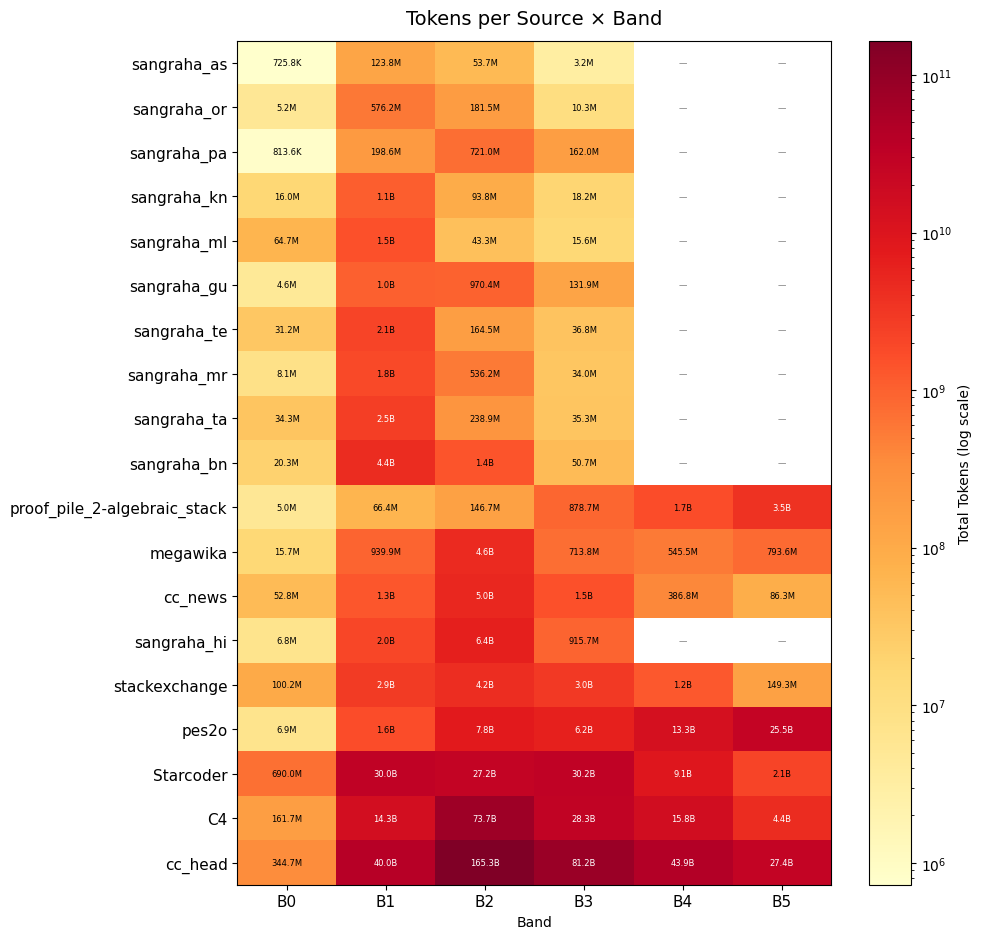

band                                 B0           B1            B2           B3           B4           B5
source                                                                                                   
sangraha_as                      725783    123762253      53677253      3164914            0            0
sangraha_or                     5201320    576209830     181467671     10345428            0            0
sangraha_pa                      813649    198554413     720961998    161952319            0            0
sangraha_kn                    16028710   1056873092      93753122     18150683            0            0
sangraha_ml                    64735088   1471127296      43281612     15586640            0            0
sangraha_gu                     4635200   1033548445     970413456    131916793            0            0
sangraha_te                    31212986   2119035732     164463545     36834887            0            0
sangraha_mr                     8079485   1828

In [4]:
# 1) Heatmap – Source × Band (log-scaled token counts)
pivot = df.pivot_table(
    index='source',
    columns='band',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot = pivot[sorted(pivot.columns)]
pivot['_total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('_total', ascending=True).drop(columns='_total')

n_rows, n_cols = pivot.shape
fig, ax = plt.subplots(figsize=(10, max(4, n_rows * 0.5)))

cmap = plt.cm.YlOrRd
log_norm = mcolors.LogNorm(
    vmin=max(pivot.values[pivot.values > 0].min(), 1),
    vmax=pivot.values.max()
)

im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, norm=log_norm)

ax.set_xticks(range(n_cols))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(pivot.index, fontsize=11)

ann_fontsize = adaptive_fontsize(n_rows, n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot.iloc[i, j]
        if val > 0:
            text = format_tokens(val)
            color = text_color_for_cell(cmap, log_norm, val)
            ax.text(j, i, text, ha='center', va='center', fontsize=ann_fontsize, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=ann_fontsize, color='gray')

plt.colorbar(im, ax=ax, label='Total Tokens (log scale)')
ax.set_title('Tokens per Source × Band', fontsize=14, pad=12)
ax.set_xlabel('Band')
plt.tight_layout()
fig.savefig('heatmap_tokens_source_band.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_source_band.png")
plt.show()

print(pivot.to_string())

Saved: barh_tokens_source_band.png


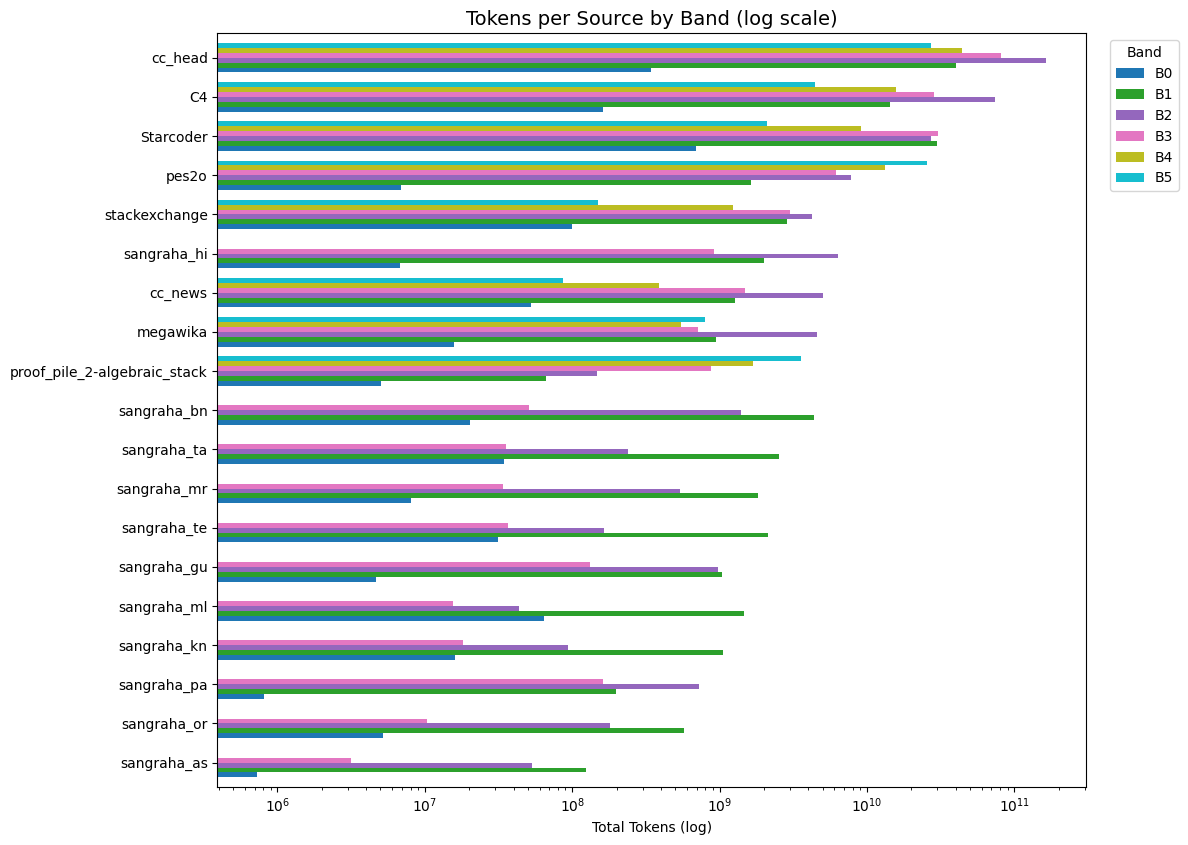

                      Source    Total Tokens
                     cc_head 358,083,801,386
                          C4 136,804,569,657
                   Starcoder  99,326,000,915
                       pes2o  54,409,509,163
               stackexchange  11,615,121,225
                 sangraha_hi   9,273,135,754
                     cc_news   8,327,308,162
                    megawika   7,583,901,229
proof_pile_2-algebraic_stack   6,320,859,588
                 sangraha_bn   5,860,075,016
                 sangraha_ta   2,844,854,581
                 sangraha_mr   2,406,882,005
                 sangraha_te   2,351,547,150
                 sangraha_gu   2,140,513,894
                 sangraha_ml   1,594,730,636
                 sangraha_kn   1,184,805,607
                 sangraha_pa   1,082,282,379
                 sangraha_or     773,224,249
                 sangraha_as     181,330,203


In [5]:
# 2) Horizontal Stacked Bar – Total tokens per source, segmented by band (log scale)
pivot_h = df.pivot_table(
    index='source',
    columns='band',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot_h = pivot_h[sorted(pivot_h.columns)]
pivot_h['_total'] = pivot_h.sum(axis=1)
pivot_h = pivot_h.sort_values('_total', ascending=True)
totals = pivot_h['_total']
pivot_h = pivot_h.drop(columns='_total')

fig, ax = plt.subplots(figsize=(12, max(4, len(pivot_h) * 0.45)))

# Use non-stacked horizontal bars (stacked + log doesn't work well)
# Instead plot each source's band breakdown as grouped bars
pivot_h.plot(kind='barh', stacked=False, ax=ax, colormap='tab10', width=0.75)

ax.set_xscale('log')
ax.set_title('Tokens per Source by Band (log scale)', fontsize=14)
ax.set_xlabel('Total Tokens (log)')
ax.set_ylabel('')
ax.legend(title='Band', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig('barh_tokens_source_band.png', dpi=150, bbox_inches='tight')
print("Saved: barh_tokens_source_band.png")
plt.show()

# Summary table
summary = df.groupby('source')['total_tokens'].sum().sort_values(ascending=False).reset_index()
summary.columns = ['Source', 'Total Tokens']
summary['Total Tokens'] = summary['Total Tokens'].apply(lambda x: f'{x:,.0f}')
print(summary.to_string(index=False))

Saved: heatmap_tokens_source_domain.png


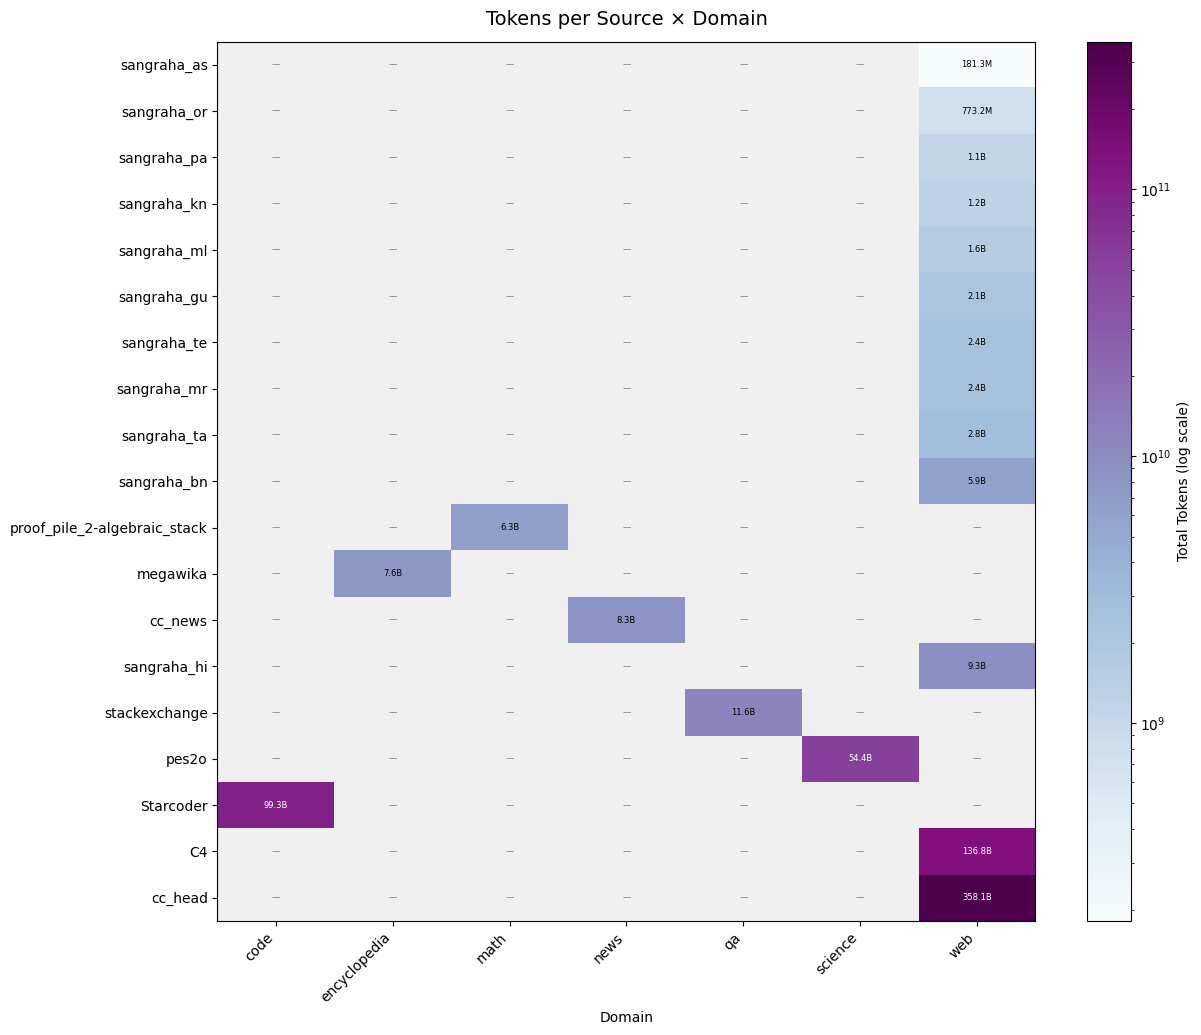

domain                               code  encyclopedia        math        news           qa      science           web
source                                                                                                                 
sangraha_as                             0             0           0           0            0            0     181330203
sangraha_or                             0             0           0           0            0            0     773224249
sangraha_pa                             0             0           0           0            0            0    1082282379
sangraha_kn                             0             0           0           0            0            0    1184805607
sangraha_ml                             0             0           0           0            0            0    1594730636
sangraha_gu                             0             0           0           0            0            0    2140513894
sangraha_te                             

In [6]:
# 3) Heatmap – Source × Domain (log-scaled token counts)
pivot_dom = df.pivot_table(
    index='source',
    columns='domain',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot_dom['_total'] = pivot_dom.sum(axis=1)
pivot_dom = pivot_dom.sort_values('_total', ascending=True).drop(columns='_total')

n_rows, n_cols = pivot_dom.shape
fig, ax = plt.subplots(figsize=(max(10, n_cols * 1.8), max(6, n_rows * 0.55)))

data = pivot_dom.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
cmap = plt.cm.BuPu
log_norm = mcolors.LogNorm(
    vmin=max(data[data > 0].min(), 1),
    vmax=data.max()
)

im = ax.imshow(masked_data, aspect='auto', cmap=cmap, norm=log_norm)
ax.set_facecolor('#f0f0f0')

ax.set_xticks(range(n_cols))
ax.set_xticklabels(pivot_dom.columns, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(pivot_dom.index, fontsize=max(8, 11 - n_rows // 10))

ann_fontsize = adaptive_fontsize(n_rows, n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_dom.iloc[i, j]
        if val > 0:
            text = format_tokens(val)
            color = text_color_for_cell(cmap, log_norm, val)
            ax.text(j, i, text, ha='center', va='center', fontsize=ann_fontsize, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=ann_fontsize, color='gray')

plt.colorbar(im, ax=ax, label='Total Tokens (log scale)')
ax.set_title('Tokens per Source × Domain', fontsize=14, pad=12)
ax.set_xlabel('Domain')
plt.tight_layout()
fig.savefig('heatmap_tokens_source_domain.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_source_domain.png")
plt.show()

print(pivot_dom.to_string())

Saved: heatmap_tokens_source_language.png


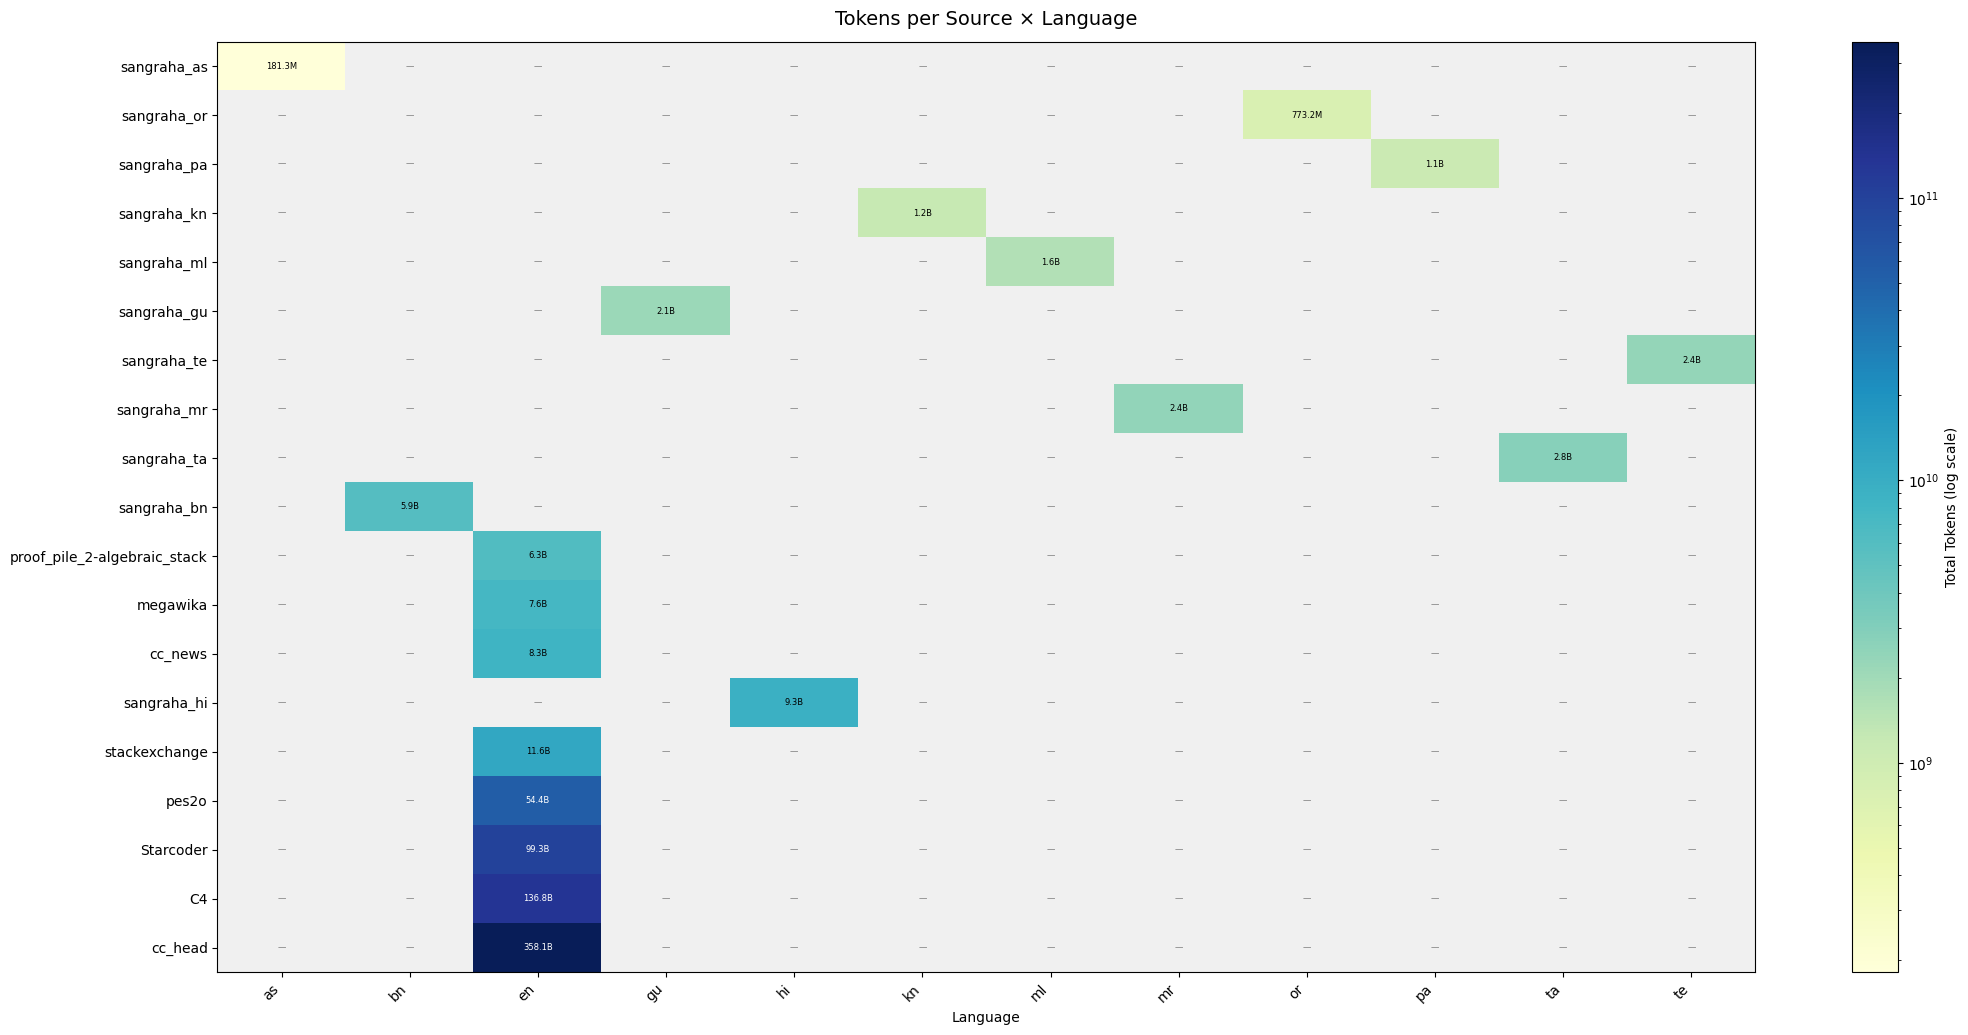

language                             as          bn            en          gu          hi          kn          ml          mr         or          pa          ta          te
source                                                                                                                                                                      
sangraha_as                   181330203           0             0           0           0           0           0           0          0           0           0           0
sangraha_or                           0           0             0           0           0           0           0           0  773224249           0           0           0
sangraha_pa                           0           0             0           0           0           0           0           0          0  1082282379           0           0
sangraha_kn                           0           0             0           0           0  1184805607           0           0          

In [7]:
# 4) Heatmap – Source × Language (log-scaled token counts)
pivot_lang = df.pivot_table(
    index='source',
    columns='language',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot_lang['_total'] = pivot_lang.sum(axis=1)
pivot_lang = pivot_lang.sort_values('_total', ascending=True).drop(columns='_total')

n_rows, n_cols = pivot_lang.shape
fig, ax = plt.subplots(figsize=(max(10, n_cols * 1.8), max(6, n_rows * 0.55)))

data = pivot_lang.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
cmap = plt.cm.YlGnBu
log_norm = mcolors.LogNorm(
    vmin=max(data[data > 0].min(), 1),
    vmax=data.max()
)

im = ax.imshow(masked_data, aspect='auto', cmap=cmap, norm=log_norm)
ax.set_facecolor('#f0f0f0')

ax.set_xticks(range(n_cols))
ax.set_xticklabels(pivot_lang.columns, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(pivot_lang.index, fontsize=max(8, 11 - n_rows // 10))

ann_fontsize = adaptive_fontsize(n_rows, n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_lang.iloc[i, j]
        if val > 0:
            text = format_tokens(val)
            color = text_color_for_cell(cmap, log_norm, val)
            ax.text(j, i, text, ha='center', va='center', fontsize=ann_fontsize, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=ann_fontsize, color='gray')

plt.colorbar(im, ax=ax, label='Total Tokens (log scale)')
ax.set_title('Tokens per Source × Language', fontsize=14, pad=12)
ax.set_xlabel('Language')
plt.tight_layout()
fig.savefig('heatmap_tokens_source_language.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_source_language.png")
plt.show()

print(pivot_lang.to_string())

Saved: heatmap_tokens_band_domain.png


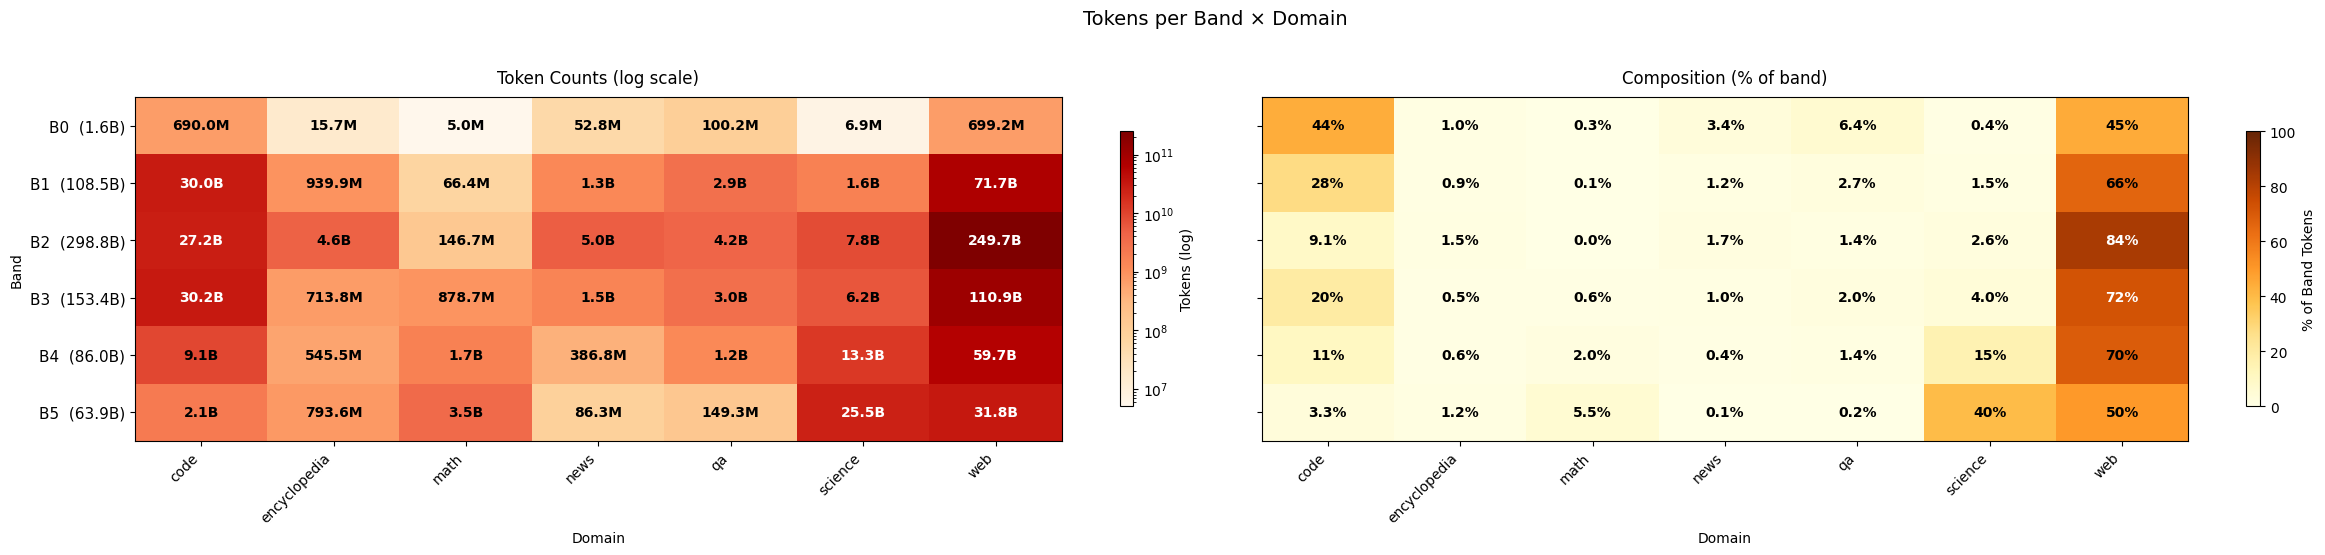


Absolute token counts per band × domain:
domain         code  encyclopedia        math        news          qa      science           web
band                                                                                            
B0        690016233      15739316     5009203    52799491   100238263      6944187     699225099
B1      30032846028     939883660    66373101  1281306316  2885417114   1638942909   71683828960
B2      27207555588    4575403056   146680467  5026813968  4238881964   7847764975  249708368858
B3      30223399020     713843715   878743640  1493336680  3010091874   6172034911  110912142535
B4       9084638953     545476527  1676270972   386750021  1231218163  13290841474   59747226484
B5       2087545093     793554955  3547782205    86301686   149273847  25452980707   31830960581

Percentage of tokens per domain within each band:
domain   code  encyclopedia  math  news    qa  science    web
band                                                         
B0     

In [8]:
# 5) Dual Heatmap – Band × Domain (absolute + percentage)
#    Left: log-scaled token counts. Right: % of band tokens per domain.

pivot_bd = df.pivot_table(
    index='band',
    columns='domain',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)
pivot_bd = pivot_bd.sort_index()

# Percentage view
pct_bd = pivot_bd.div(pivot_bd.sum(axis=1), axis=0).fillna(0) * 100

# Shortened band labels
band_totals = pivot_bd.sum(axis=1)
band_labels = [f"{b}  ({format_tokens(band_totals[b])})" for b in pivot_bd.index]

n_rows, n_cols = pivot_bd.shape
panel_width = max(6, n_cols * 1.6)
fig_height = max(4, n_rows * 0.9)
fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(panel_width * 2 + 2, fig_height),
                                       sharey=True)

# --- Left panel: absolute token counts (log scale) ---
data = pivot_bd.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
pos_vals = data[data > 0]

cmap_abs = plt.cm.OrRd
if len(pos_vals) > 0:
    log_norm = mcolors.LogNorm(vmin=max(pos_vals.min(), 1), vmax=pos_vals.max())
    im_abs = ax_abs.imshow(masked_data, aspect='auto', cmap=cmap_abs, norm=log_norm)
    plt.colorbar(im_abs, ax=ax_abs, label='Tokens (log)', shrink=0.8)
else:
    im_abs = ax_abs.imshow(data, aspect='auto', cmap=cmap_abs)

ax_abs.set_facecolor('#f0f0f0')
ax_abs.set_xticks(range(n_cols))
ax_abs.set_xticklabels(pivot_bd.columns, fontsize=10, rotation=45, ha='right')
ax_abs.set_yticks(range(n_rows))
ax_abs.set_yticklabels(band_labels, fontsize=11)

ann_fs = adaptive_fontsize(n_rows, n_cols, base=10)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_bd.iloc[i, j]
        if val > 0:
            color = text_color_for_cell(cmap_abs, log_norm, val)
            ax_abs.text(j, i, format_tokens(val), ha='center', va='center',
                        fontsize=ann_fs, color=color, fontweight='bold')
        else:
            ax_abs.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

ax_abs.set_title('Token Counts (log scale)', fontsize=12, pad=10)
ax_abs.set_xlabel('Domain')
ax_abs.set_ylabel('Band')

# --- Right panel: percentage composition (linear 0-100%) ---
cmap_pct = plt.cm.YlOrBr
pct_data = pct_bd.values.astype(float)
masked_pct = np.ma.masked_where(pct_data == 0, pct_data)
pct_norm = mcolors.Normalize(vmin=0, vmax=100)

im_pct = ax_pct.imshow(masked_pct, aspect='auto', cmap=cmap_pct, norm=pct_norm)
ax_pct.set_facecolor('#f0f0f0')

ax_pct.set_xticks(range(n_cols))
ax_pct.set_xticklabels(pivot_bd.columns, fontsize=10, rotation=45, ha='right')

for i in range(n_rows):
    for j in range(n_cols):
        val = pct_bd.iloc[i, j]
        if val > 0:
            label = f'{val:.1f}%' if val < 10 else f'{val:.0f}%'
            color = text_color_for_cell(cmap_pct, pct_norm, val)
            ax_pct.text(j, i, label, ha='center', va='center',
                        fontsize=ann_fs, color=color, fontweight='bold')
        else:
            ax_pct.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

plt.colorbar(im_pct, ax=ax_pct, label='% of Band Tokens', shrink=0.8)
ax_pct.set_title('Composition (% of band)', fontsize=12, pad=10)
ax_pct.set_xlabel('Domain')

fig.suptitle('Tokens per Band × Domain', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('heatmap_tokens_band_domain.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_band_domain.png")
plt.show()

print("\nAbsolute token counts per band × domain:")
print(pivot_bd.to_string())
print("\nPercentage of tokens per domain within each band:")
print(pct_bd.round(2).to_string())

In [9]:
# # 6) Dual Heatmap – Band × Language (absolute + percentage)
# #    Left: log-scaled token counts. Right: % of band tokens per language.

# pivot_bl = df.pivot_table(
#     index='band',
#     columns='language',
#     values='total_tokens',
#     aggfunc='sum',
#     fill_value=0
# )
# pivot_bl = pivot_bl.sort_index()

# # Percentage view
# pct_bl = pivot_bl.div(pivot_bl.sum(axis=1), axis=0).fillna(0) * 100

# # Shortened band labels
# band_totals = pivot_bl.sum(axis=1)
# band_labels = [f"{b}  ({format_tokens(band_totals[b])})" for b in pivot_bl.index]

# n_rows, n_cols = pivot_bl.shape
# panel_width = max(6, n_cols * 1.6)
# fig_height = max(4, n_rows * 0.9)
# fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(panel_width * 2 + 2, fig_height),
#                                        sharey=True)

# # --- Left panel: absolute token counts (log scale) ---
# data = pivot_bl.values.astype(float)
# masked_data = np.ma.masked_where(data == 0, data)
# pos_vals = data[data > 0]

# cmap_abs = plt.cm.GnBu
# if len(pos_vals) > 0:
#     log_norm = mcolors.LogNorm(vmin=max(pos_vals.min(), 1), vmax=pos_vals.max())
#     im_abs = ax_abs.imshow(masked_data, aspect='auto', cmap=cmap_abs, norm=log_norm)
#     plt.colorbar(im_abs, ax=ax_abs, label='Tokens (log)', shrink=0.8)
# else:
#     im_abs = ax_abs.imshow(data, aspect='auto', cmap=cmap_abs)

# ax_abs.set_facecolor('#f0f0f0')
# ax_abs.set_xticks(range(n_cols))
# ax_abs.set_xticklabels(pivot_bl.columns, fontsize=10, rotation=45, ha='right')
# ax_abs.set_yticks(range(n_rows))
# ax_abs.set_yticklabels(band_labels, fontsize=11)

# ann_fs = adaptive_fontsize(n_rows, n_cols, base=10)
# for i in range(n_rows):
#     for j in range(n_cols):
#         val = pivot_bl.iloc[i, j]
#         if val > 0:
#             color = text_color_for_cell(cmap_abs, log_norm, val)
#             ax_abs.text(j, i, format_tokens(val), ha='center', va='center',
#                         fontsize=ann_fs, color=color, fontweight='bold')
#         else:
#             ax_abs.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

# ax_abs.set_title('Token Counts (log scale)', fontsize=12, pad=10)
# ax_abs.set_xlabel('Language')
# ax_abs.set_ylabel('Band')

# # --- Right panel: percentage composition (linear 0-100%) ---
# cmap_pct = plt.cm.PuBuGn
# pct_data = pct_bl.values.astype(float)
# masked_pct = np.ma.masked_where(pct_data == 0, pct_data)
# pct_norm = mcolors.Normalize(vmin=0, vmax=100)

# im_pct = ax_pct.imshow(masked_pct, aspect='auto', cmap=cmap_pct, norm=pct_norm)
# ax_pct.set_facecolor('#f0f0f0')

# ax_pct.set_xticks(range(n_cols))
# ax_pct.set_xticklabels(pivot_bl.columns, fontsize=10, rotation=45, ha='right')

# for i in range(n_rows):
#     for j in range(n_cols):
#         val = pct_bl.iloc[i, j]
#         if val > 0:
#             label = f'{val:.1f}%' if val < 10 else f'{val:.0f}%'
#             color = text_color_for_cell(cmap_pct, pct_norm, val)
#             ax_pct.text(j, i, label, ha='center', va='center',
#                         fontsize=ann_fs, color=color, fontweight='bold')
#         else:
#             ax_pct.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

# plt.colorbar(im_pct, ax=ax_pct, label='% of Band Tokens', shrink=0.8)
# ax_pct.set_title('Composition (% of band)', fontsize=12, pad=10)
# ax_pct.set_xlabel('Language')

# fig.suptitle('Tokens per Band × Language', fontsize=14, y=1.02)
# plt.tight_layout()
# fig.savefig('heatmap_tokens_band_language.png', dpi=150, bbox_inches='tight')
# print("Saved: heatmap_tokens_band_language.png")
# plt.show()

# print("\nAbsolute token counts per band × language:")
# print(pivot_bl.to_string())
# print("\nPercentage of tokens per language within each band:")
# print(pct_bl.round(2).to_string())